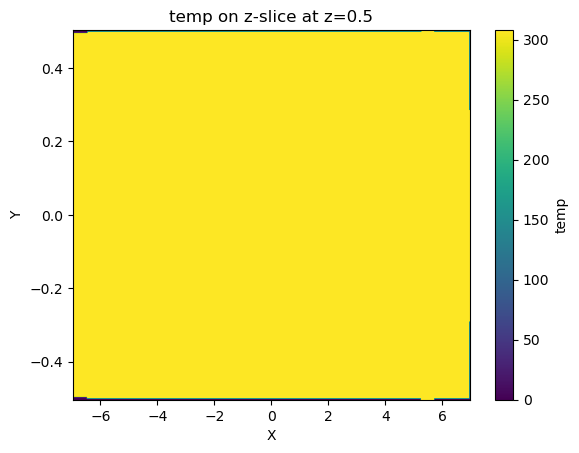

In [1]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

mesh = pv.read("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

z0 = .5
sl = mesh.slice(normal="z", origin=(0, 0, z0))

# x0 = 2  # pick an x inside mesh.bounds
# sl = mesh.slice(normal="x", origin=(x0, 0, 0))
# y0 = 1  # pick an x inside mesh.bounds
# sl = mesh.slice(normal="y", origin=(0, y0, 0))

# Ensure temp is point data on the slice
if "temp" not in sl.point_data:
    if "temp" in sl.cell_data:
        sl = sl.cell_data_to_point_data()
    else:
        raise ValueError("temp not found in slice.")

# Define a uniform 2D grid in XY at z=z0
nx, ny = 800, 250
xmin, xmax, ymin, ymax = sl.bounds[0], sl.bounds[1], sl.bounds[2], sl.bounds[3]

x = np.linspace(xmin, xmax, nx)
y = np.linspace(ymin, ymax, ny)
xx, yy = np.meshgrid(x, y)

# Build a point cloud grid (nx*ny points) at constant z0
pts = np.c_[xx.ravel(), yy.ravel(), np.full(xx.size, z0)]
grid = pv.PolyData(pts)

# Sample temperature from the slice onto the grid
sampled = grid.sample(sl)

temp = sampled["temp"].reshape(ny, nx)

# Values with no data become 0 or NaN depending on VTK; mask zeros if needed:
# temp = np.where(temp == 0, np.nan, temp)

plt.figure()
plt.imshow(
    temp,
    origin="lower",
    extent=[xmin, xmax, ymin, ymax],
    aspect="auto",
)
plt.colorbar(label="temp")
plt.title(f"temp on z-slice at z={z0}")
plt.xlabel("X")
plt.ylabel("Y")
plt.show()

In [12]:
import pyvista as pv
import numpy as np

# mesh = pv.read("wall_1.vtk")
mesh = pv.read("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

print("point_data:", mesh.point_data.keys())
print("cell_data :", mesh.cell_data.keys())
print("field_data:", mesh.field_data.keys())

# Promote field_data arrays (length == n_points) to point_data
for name in mesh.field_data.keys():
    arr = mesh.field_data[name]
    # handle (n,) or (n,1)
    arr = np.asarray(arr)
    if arr.shape[0] == mesh.n_points:
        mesh.point_data[name] = arr.reshape(mesh.n_points, -1)[:, 0] if arr.ndim == 2 and arr.shape[1] == 1 else arr

# Now these should work as point scalars:
# mesh.point_data["S_von"], mesh.point_data["S11"], etc.

point_data: ['temp', 'S_von', 'S11', 'S22', 'S33', 'S12', 'S23', 'S13', 'U1', 'U2', 'U3']
cell_data : []
field_data: []


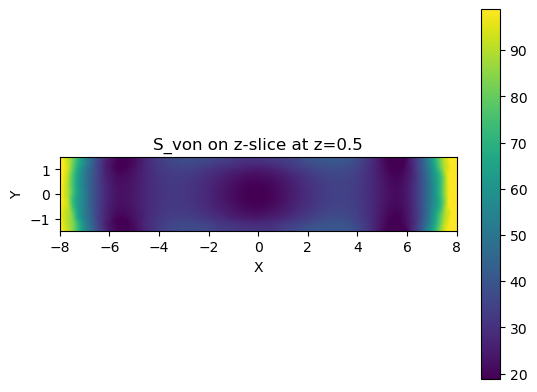

In [ ]:
import pyvista as pv
import numpy as np
import matplotlib.pyplot as plt

def slice_plane_to_grids(mesh, axis, value, scalars="S_von", n1=800, n2=250, mask_invalid=True):
    if scalars not in mesh.point_data:
        raise ValueError(f'"{scalars}" not in point_data. Available: {list(mesh.point_data.keys())}')

    xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds
    axis = axis.lower()

    if axis == "z":
        center = (0.5*(xmin+xmax), 0.5*(ymin+ymax), value)
        direction = (0, 0, 1)
        i_size, j_size = (xmax-xmin), (ymax-ymin)  # x by y
        nx, ny = n1, n2
        xlab, ylab = "X", "Y"
    elif axis == "x":
        center = (value, 0.5*(ymin+ymax), 0.5*(zmin+zmax))
        direction = (1, 0, 0)
        i_size, j_size = (ymax-ymin), (zmax-zmin)  # y by z
        nx, ny = n1, n2
        xlab, ylab = "Y", "Z"
    elif axis == "y":
        center = (0.5*(xmin+xmax), value, 0.5*(zmin+zmax))
        direction = (0, 1, 0)
        i_size, j_size = (xmax-xmin), (zmax-zmin)  # x by z
        nx, ny = n1, n2
        xlab, ylab = "X", "Z"
    else:
        raise ValueError("axis must be 'x', 'y', or 'z'")

    plane = pv.Plane(
        center=center,
        direction=direction,
        i_size=i_size,
        j_size=j_size,
        i_resolution=nx-1,
        j_resolution=ny-1,
    )

    sampled = plane.sample(mesh)

    # Key: C-order reshape for plane samples (avoids stripe artifact)
    pts = sampled.points.reshape((ny, nx, 3), order="C")
    X, Y, Z = pts[:, :, 0], pts[:, :, 1], pts[:, :, 2]
    V = sampled[scalars].reshape((ny, nx), order="C")

    valid = None
    if "vtkValidPointMask" in sampled.point_data:
        valid = sampled["vtkValidPointMask"].reshape((ny, nx), order="C").astype(bool)
        if mask_invalid:
            V = np.where(valid, V, np.nan)

    return X, Y, Z, V, valid, (xlab, ylab)

def plot_slice(X, Y, V, xlab="X", ylab="Y", title="", robust=True):
    fig, ax = plt.subplots()
    m = np.isfinite(V)

    # Optional robust color scaling (helps when values are almost constant)
    if robust and np.any(m):
        vmin, vmax = np.nanpercentile(V, [2, 98])
    else:
        vmin, vmax = None, None

    pcm = ax.pcolormesh(X, Y, V, shading="auto", vmin=vmin, vmax=vmax)
    fig.colorbar(pcm, ax=ax)

    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")

    # Auto-zoom to valid region
    if np.any(m):
        ax.set_xlim(X[m].min(), X[m].max())
        ax.set_ylim(Y[m].min(), Y[m].max())

    plt.show()

# Example usage
mesh = pv.read("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

X, Y, Z, V, valid, (xlab, ylab) = slice_plane_to_grids(mesh, axis="z", value=-4, scalars="S_von", n1=800, n2=250)
plot_slice(X, Y, V, xlab=xlab, ylab=ylab, title="S_von on z-slice at z=0.5")

X, Y, Z, V, valid, (xlab, ylab) = slice_plane_to_grids(mesh, axis="z", value=-4, scalars="S_von", n1=800, n2=250)
plot_slice(X, Y, V, xlab=xlab, ylab=ylab, title="S_von on z-slice at z=0.5")

/tmp/ipykernel_757288/3827689015.py:77: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(X[m].min(), X[m].max())


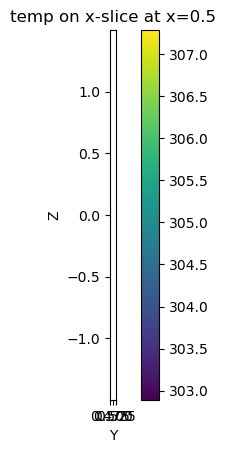

In [21]:
X, Y, Z, V, valid, labs = slice_plane_to_grids(mesh, "x", 0.5, scalars="temp")
xlab, ylab = labs
plot_slice(X, Y, V, xlab=xlab, ylab=ylab, title="temp on x-slice at x=0.5")

In [36]:
import numpy as np
import pyvista as pv


class DEDVTK:
    """
    Convenience class for DED solver VTK outputs.

    Common fields (often):
      - temp
      - S_von, S11, S22, S33, S12, S23, S13
      - U1, U2, U3

    Features:
      - slice_plane(axis, value, scalars, ...) -> structured grids + values
      - plot_slice(...) and plot_slice_index(...) for quick visualization
      - volume_average(scalars) -> volume-weighted average (fallback to point-mean)
      - summaries_for_bo(...) -> dictionary of common metrics
      - resample_to_volume(...) -> uniform 3D volume for fast numpy slicing
    """

    def __init__(self, vtk_path: str):
        self.vtk_path = vtk_path
        self.mesh = pv.read(vtk_path)
        self._promote_field_data()

    # ---------- basic info ----------
    @property
    def bounds(self):
        return self.mesh.bounds  # (xmin, xmax, ymin, ymax, zmin, zmax)

    @property
    def point_fields(self):
        return list(self.mesh.point_data.keys())

    @property
    def cell_fields(self):
        return list(self.mesh.cell_data.keys())

    def has(self, name: str) -> bool:
        return (name in self.mesh.point_data) or (name in self.mesh.cell_data) or (name in self.mesh.field_data)

    # ---------- internal helpers ----------
    def _promote_field_data(self):
        """
        If arrays are stored in field_data, promote them to point_data or cell_data
        when their first dimension matches n_points or n_cells.
        """
        for name in list(self.mesh.field_data.keys()):
            arr = np.asarray(self.mesh.field_data[name])
            if arr.ndim == 2 and arr.shape[1] == 1:
                arr = arr[:, 0]
            if arr.ndim >= 1 and arr.shape[0] == self.mesh.n_points:
                self.mesh.point_data[name] = arr
            elif arr.ndim >= 1 and arr.shape[0] == self.mesh.n_cells:
                self.mesh.cell_data[name] = arr

    def _ensure_point_scalar(self, scalars: str) -> pv.DataSet:
        """
        Return a mesh where `scalars` is available in point_data.
        If only cell_data exists, convert cell->point.
        """
        if scalars in self.mesh.point_data:
            return self.mesh
        if scalars in self.mesh.cell_data:
            return self.mesh.cell_data_to_point_data()
        raise ValueError(f'"{scalars}" not found. point={self.point_fields}, cell={self.cell_fields}')

    # ---------- slicing (structured plane) ----------
    def slice_plane(
        self,
        axis: str,
        value: float,
        scalars: str = "temp",
        n1: int = 800,
        n2: int = 250,
        pad: float = 0.0,
        mask_invalid: bool = True,
    ):
        """
        Sample onto a structured plane and return:
          (X, Y, Z, V, valid_mask, (xlabel, ylabel))

        axis='x' returns a Y-Z plane at x=value
        axis='y' returns an X-Z plane at y=value
        axis='z' returns an X-Y plane at z=value

        IMPORTANT: Uses order='C' reshape (prevents stripe/barcode artifacts).
        """
        mesh = self._ensure_point_scalar(scalars)

        xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds
        xmin -= pad; xmax += pad
        ymin -= pad; ymax += pad
        zmin -= pad; zmax += pad

        axis = axis.lower().strip()
        if axis == "z":
            center = (0.5 * (xmin + xmax), 0.5 * (ymin + ymax), value)
            direction = (0.0, 0.0, 1.0)
            i_size, j_size = (xmax - xmin), (ymax - ymin)
            nx, ny = n1, n2
            xlabel, ylabel = "X", "Y"
        elif axis == "x":
            center = (value, 0.5 * (ymin + ymax), 0.5 * (zmin + zmax))
            direction = (1.0, 0.0, 0.0)
            i_size, j_size = (ymax - ymin), (zmax - zmin)
            nx, ny = n1, n2
            xlabel, ylabel = "Y", "Z"
        elif axis == "y":
            center = (0.5 * (xmin + xmax), value, 0.5 * (zmin + zmax))
            direction = (0.0, 1.0, 0.0)
            i_size, j_size = (xmax - xmin), (zmax - zmin)
            nx, ny = n1, n2
            xlabel, ylabel = "X", "Z"
        else:
            raise ValueError("axis must be one of: 'x', 'y', 'z'")

        plane = pv.Plane(
            center=center,
            direction=direction,
            i_size=i_size,
            j_size=j_size,
            i_resolution=nx - 1,
            j_resolution=ny - 1,
        )

        sampled = plane.sample(mesh)

        # vtkPlaneSource ordering -> reshape with C-order
        pts = sampled.points.reshape((ny, nx, 3), order="C")
        X = pts[:, :, 0]
        Y = pts[:, :, 1]
        Z = pts[:, :, 2]

        V = sampled[scalars].reshape((ny, nx), order="C")

        if "vtkValidPointMask" in sampled.point_data:
            valid = sampled["vtkValidPointMask"].reshape((ny, nx), order="C").astype(bool)
        else:
            valid = np.ones((ny, nx), dtype=bool)

        if mask_invalid:
            V = np.where(valid, V, np.nan)

        return X, Y, Z, V, valid, (xlabel, ylabel)

    # ---------- visualization helpers ----------
    def plot_slice(
        self,
        axis: str,
        value: float,
        scalars: str = "temp",
        n1: int = 800,
        n2: int = 250,
        pad: float = 0.0,
        mask_invalid: bool = True,
        robust: bool = True,
        cmap: str | None = None,
        title: str | None = None,
        show: bool = True,
        ax=None,
    ):
        """
        Plot a scalar on a plane slice using matplotlib.

        Returns:
          (fig, ax, (X, Y, Z, V, valid, (xlabel, ylabel)))
        """
        import matplotlib.pyplot as plt

        X, Y, Z, V, valid, (xlabel, ylabel) = self.slice_plane(
            axis=axis,
            value=value,
            scalars=scalars,
            n1=n1,
            n2=n2,
            pad=pad,
            mask_invalid=mask_invalid,
        )

        axis_l = axis.lower().strip()
        if axis_l == "x":
            A, B = Y, Z  # Y-Z plane
            xlab, ylab = "Y", "Z"
        elif axis_l == "y":
            A, B = X, Z  # X-Z plane
            xlab, ylab = "X", "Z"
        else:
            A, B = X, Y  # X-Y plane
            xlab, ylab = "X", "Y"

        m = np.isfinite(V)
        vmin = vmax = None
        if robust and np.any(m):
            vmin, vmax = np.nanpercentile(V, [2, 98])

        if ax is None:
            fig, ax = plt.subplots()
        else:
            fig = ax.figure

        pcm = ax.pcolormesh(A, B, V, shading="auto", vmin=vmin, vmax=vmax, cmap=cmap)
        fig.colorbar(pcm, ax=ax, label=scalars)

        ax.set_xlabel(xlab)
        ax.set_ylabel(ylab)
        ax.set_aspect("equal", adjustable="box")

        if title is None:
            title = f"{scalars} on {axis_l}-slice at {axis_l}={value}"
        ax.set_title(title)

        # Auto-zoom to valid region
        if np.any(m):
            ax.set_xlim(A[m].min(), A[m].max())
            ax.set_ylim(B[m].min(), B[m].max())

        if show:
            plt.show()

        return fig, ax, (X, Y, Z, V, valid, (xlabel, ylabel))

    def _axis_value_from_index(self, axis: str, index: int, n: int = 200) -> float:
        """
        Map an index in [0, n-1] to a coordinate value uniformly within mesh bounds.
        """
        xmin, xmax, ymin, ymax, zmin, zmax = self.bounds
        axis_l = axis.lower().strip()
        index = int(np.clip(index, 0, n - 1))
        if axis_l == "x":
            return float(np.linspace(xmin, xmax, n)[index])
        if axis_l == "y":
            return float(np.linspace(ymin, ymax, n)[index])
        if axis_l == "z":
            return float(np.linspace(zmin, zmax, n)[index])
        raise ValueError("axis must be 'x', 'y', or 'z'")

    def plot_slice_index(
        self,
        axis: str,
        index: int,
        scalars: str = "temp",
        index_grid_n: int = 200,
        n1: int = 800,
        n2: int = 250,
        pad: float = 0.0,
        mask_invalid: bool = True,
        robust: bool = True,
        cmap: str | None = None,
        title: str | None = None,
        show: bool = True,
        ax=None,
    ):
        """
        Plot a slice using an index instead of a coordinate.
        Index is mapped uniformly across bounds (not by actual node layers).
        """
        idx = int(np.clip(index, 0, index_grid_n - 1))
        value = self._axis_value_from_index(axis, idx, n=index_grid_n)

        if title is None:
            title = f"{scalars} on {axis.lower()}-slice index {idx} (coord {value:.4g})"

        return self.plot_slice(
            axis=axis,
            value=value,
            scalars=scalars,
            n1=n1,
            n2=n2,
            pad=pad,
            mask_invalid=mask_invalid,
            robust=robust,
            cmap=cmap,
            title=title,
            show=show,
            ax=ax,
        )

    # ---------- averages for BO ----------
    def volume_average(self, scalars: str, ignore_nan: bool = True) -> float:
        """
        Volume-weighted average of `scalars` over the whole mesh.
        Falls back to point-mean if volume calculation fails.
        """
        try:
            # Work in cell space for volume weights
            if scalars in self.mesh.point_data and scalars not in self.mesh.cell_data:
                m = self.mesh.point_data_to_cell_data(pass_point_data=False)
            else:
                m = self.mesh.copy()

            if scalars not in m.cell_data:
                m = m.point_data_to_cell_data(pass_point_data=False)

            m = m.compute_cell_sizes(volume=True)
            vols = np.asarray(m.cell_data["Volume"])
            vals = np.asarray(m.cell_data[scalars])

            if ignore_nan:
                ok = np.isfinite(vals) & np.isfinite(vols) & (vols > 0)
                vols, vals = vols[ok], vals[ok]

            return float(np.sum(vals * vols) / np.sum(vols))
        except Exception:
            mesh = self._ensure_point_scalar(scalars)
            vals = np.asarray(mesh.point_data[scalars])
            if ignore_nan:
                vals = vals[np.isfinite(vals)]
            return float(np.mean(vals))

    def summaries_for_bo(self, stress_scalar: str = "S_von") -> dict:
        """
        Summary metrics you can log per VTK file for your BO loop.
        """
        out = {
            "vtk_path": self.vtk_path,
            "temp_avg": self.volume_average("temp") if self.has("temp") else None,
            "temp_max": float(np.nanmax(np.asarray(self._ensure_point_scalar("temp").point_data["temp"]))) if self.has("temp") else None,
            "stress_avg": self.volume_average(stress_scalar) if self.has(stress_scalar) else None,
            "stress_max": float(np.nanmax(np.asarray(self._ensure_point_scalar(stress_scalar).point_data[stress_scalar]))) if self.has(stress_scalar) else None,
        }
        return out

    # ---------- optional: uniform volume for fast numpy slicing ----------
    def resample_to_volume(
        self,
        scalars: str = "temp",
        nx: int = 220,
        ny: int = 120,
        nz: int = 120,
        pad: float = 0.0,
        mask_invalid: bool = True,
    ):
        """
        Resample an unstructured mesh to a uniform ImageData volume.

        Returns:
          V_zyx, x, y, z, valid_zyx
          - V_zyx has shape (nz, ny, nx)
          - x, y, z are 1D axes arrays

        Ideal for many slices with pure NumPy indexing:
          V_xy = V_zyx[k, :, :]  (z-slice)
        """
        mesh = self._ensure_point_scalar(scalars)

        xmin, xmax, ymin, ymax, zmin, zmax = mesh.bounds
        xmin -= pad; xmax += pad
        ymin -= pad; ymax += pad
        zmin -= pad; zmax += pad

        dx = (xmax - xmin) / (nx - 1)
        dy = (ymax - ymin) / (ny - 1)
        dz = (zmax - zmin) / (nz - 1)

        vol = pv.ImageData(
            dimensions=(nx, ny, nz),
            spacing=(dx, dy, dz),
            origin=(xmin, ymin, zmin),
        )

        sampled = vol.sample(mesh)

        # ImageData stored with x fastest, then y, then z (Fortran reshape)
        V_xyz = sampled[scalars].reshape((nx, ny, nz), order="F")
        V_zyx = np.transpose(V_xyz, (2, 1, 0))  # (z, y, x)

        if "vtkValidPointMask" in sampled.point_data:
            valid_xyz = sampled["vtkValidPointMask"].reshape((nx, ny, nz), order="F").astype(bool)
            valid_zyx = np.transpose(valid_xyz, (2, 1, 0))
        else:
            valid_zyx = np.ones_like(V_zyx, dtype=bool)

        if mask_invalid:
            V_zyx = np.where(valid_zyx, V_zyx, np.nan)

        x = xmin + dx * np.arange(nx)
        y = ymin + dy * np.arange(ny)
        z = zmin + dz * np.arange(nz)

        return V_zyx, x, y, z, valid_zyx

/tmp/ipykernel_757288/3830736332.py:203: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  pcm = ax.pcolormesh(A, B, V, shading="auto", vmin=vmin, vmax=vmax, cmap=cmap)


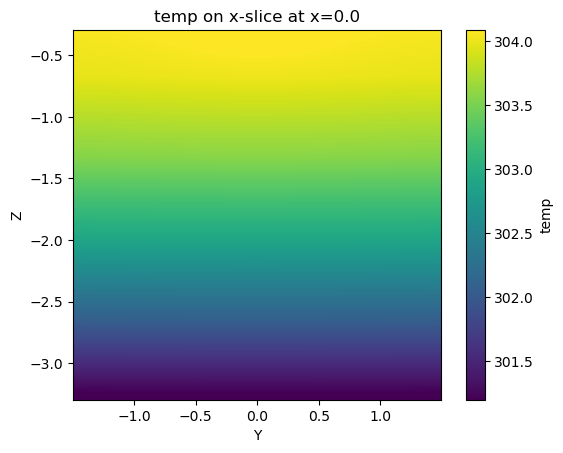

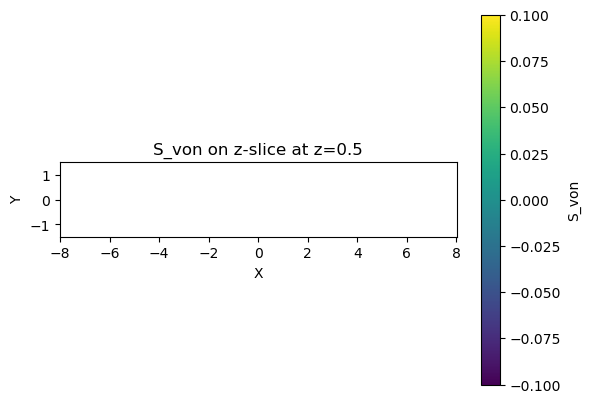

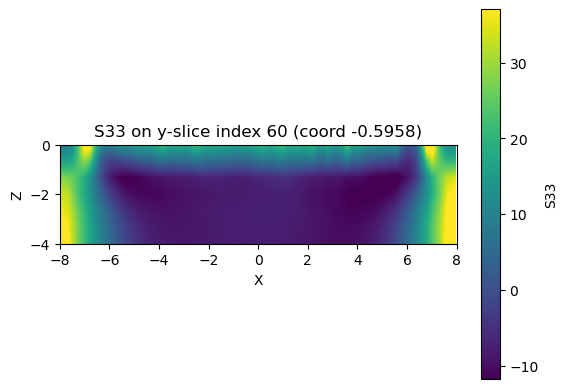

(<Figure size 640x480 with 2 Axes>,
 <Axes: title={'center': 'S33 on y-slice index 60 (coord -0.5958)'}, xlabel='X', ylabel='Z'>,
 (pyvista_ndarray([[-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   ...,
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ],
                   [-8.       , -7.9799747, -7.95995  , ...,  7.95995  ,
                     7.9799747,  8.       ]], dtype=float32),
  pyvista_ndarray([[-0.59581697, -0.59581697, -0.59581697, ...,
                    -0.59581697, -0.59581697, -0.59581697

In [42]:
d = DEDVTK("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_1.vtk")

# Temperature at x = midpoint of bounds
xmin, xmax, ymin, ymax, zmin, zmax = d.bounds
x0 = 0.5*(xmin + xmax)
d.plot_slice(axis="x", value=x0, scalars="temp")
# Von Mises stress at z = 0.5
d.plot_slice(axis="z", value=0.5, scalars="S_von")
# Stress component S33 at y-index = 60 (index mapped over bounds)
d.plot_slice_index(axis="y", index=60, scalars="S33", index_grid_n=200)

Max S_von: 822.523


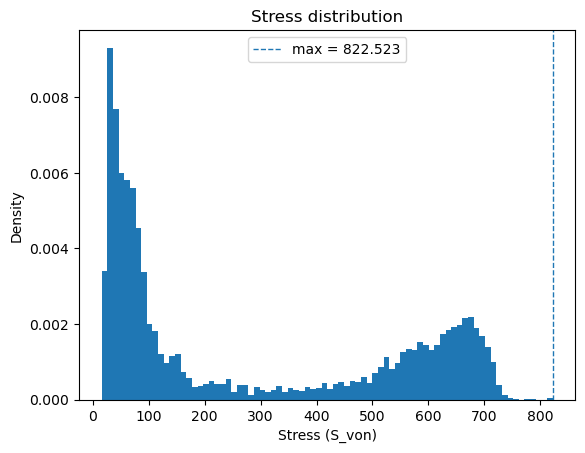

Max temp: 308.049


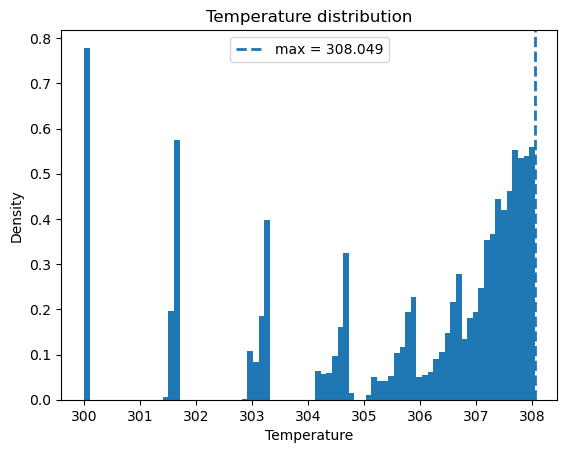

In [69]:
import numpy as np
import matplotlib.pyplot as plt

d = DEDVTK("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

stress = np.asarray(d.mesh.point_data["S_von"])
stress = stress[np.isfinite(stress)]

smax = float(np.max(stress))
print(f"Max S_von: {smax:.6g}")

plt.figure()
plt.hist(stress, bins=80, density=True)   # density=True matches your y-label
plt.axvline(smax, linestyle="--", linewidth=1, label=f"max = {smax:.6g}")
plt.xlabel("Stress (S_von)")
plt.ylabel("Density")
plt.title("Stress distribution")
plt.legend()
plt.show()

temp = np.asarray(d.mesh.point_data["temp"])
temp = temp[np.isfinite(temp)]

tmax = float(np.max(temp))
print(f"Max temp: {tmax:.6g}")

plt.figure()
plt.hist(temp, bins=80, density=True)
plt.axvline(tmax, linestyle="--", linewidth=2, label=f"max = {tmax:.6g}")
plt.xlabel("Temperature")
plt.ylabel("Density")
plt.title("Temperature distribution")
plt.legend()
plt.show()

Max cell temp: 308.048


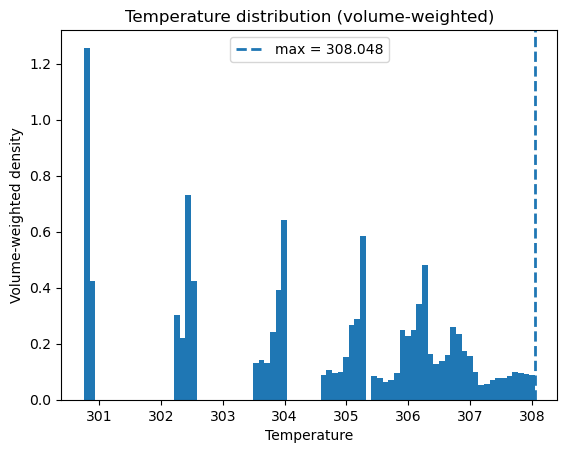

In [66]:
import numpy as np
import matplotlib.pyplot as plt

d = DEDVTK("/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_3.vtk")

m = d.mesh
if "temp" in m.point_data and "temp" not in m.cell_data:
    m = m.point_data_to_cell_data(pass_point_data=False)

m = m.compute_cell_sizes(volume=True)
vals = np.asarray(m.cell_data["temp"])
w = np.asarray(m.cell_data["Volume"])

ok = np.isfinite(vals) & np.isfinite(w) & (w > 0)
vals, w = vals[ok], w[ok]

tmax = float(np.max(vals))
print(f"Max cell temp: {tmax:.6g}")

plt.figure()
plt.hist(vals, bins=80, weights=w, density=True)
plt.axvline(tmax, linestyle="--", linewidth=2, label=f"max = {tmax:.6g}")
plt.xlabel("Temperature")
plt.ylabel("Volume-weighted density")
plt.title("Temperature distribution (volume-weighted)")
plt.legend()
plt.show()

In [70]:
import re
from glob import glob
import numpy as np
import pyvista as pv

def step_from_name(path):
    m = re.findall(r"\d+", path)
    return int(m[-1]) if m else -1

def heat_treatment_time_from_vtks(vtk_glob, Tmin, Tmax, dt):
    files = sorted(glob(vtk_glob), key=step_from_name)
    if not files:
        raise FileNotFoundError(f"No files matched: {vtk_glob}")

    temps = []
    for f in files:
        mesh = pv.read(f)
        if "temp" not in mesh.point_data:
            raise ValueError(f'"temp" not found in {f}')
        temps.append(np.asarray(mesh.point_data["temp"], dtype=np.float32))

    T = np.stack(temps, axis=0)  # shape (n_time, n_nodes)

    in_band = (T >= Tmin) & (T <= Tmax)          # (n_time, n_nodes)
    any_in = in_band.any(axis=0)                 # (n_nodes,)

    # first index in band
    first = np.full(T.shape[1], -1, dtype=int)
    first[any_in] = in_band[:, any_in].argmax(axis=0)

    # last index in band
    last = np.full(T.shape[1], -1, dtype=int)
    last[any_in] = (T.shape[0] - 1) - in_band[::-1, any_in].argmax(axis=0)

    # first-to-last span (matches the paper definition)
    per_node_time = (last - first) * dt          # seconds
    avg_time = float(per_node_time[any_in].mean())

    return avg_time, per_node_time, files

# Example for IN718 band (convert C -> K if your temps are in Kelvin):
Tmin = 654 + 273.15
Tmax = 857 + 273.15

# You must set dt based on how often you saved VTKs (seconds per file)
avg_heat_time, per_node_heat_time, files = heat_treatment_time_from_vtks(
    "/data/zhq7531/classes/optimization/ded_dt_thermomechanical_solver/examples/wall/results/wall_*.vtk",
    Tmin=Tmin, Tmax=Tmax, dt=0.02
)

print("Average heat treatment time (s):", avg_heat_time)

ValueError: all input arrays must have the same shape